     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128 | CUDA available: True | device: 0
Working directory: /kaggle/working
Mode: PRE-TRAINED MODEL (fast path)
Using pre-trained model directly: yolov8n.pt (no training).
Found 6 video(s); 5 preferred (non-output) candidate(s).
Using: /kaggle/input/datasets/jayantvaibhav/viedo-data/istockphoto-1834484979-640_adpp_is.mp4
ElevatorOccupancyDetector class ready.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 3

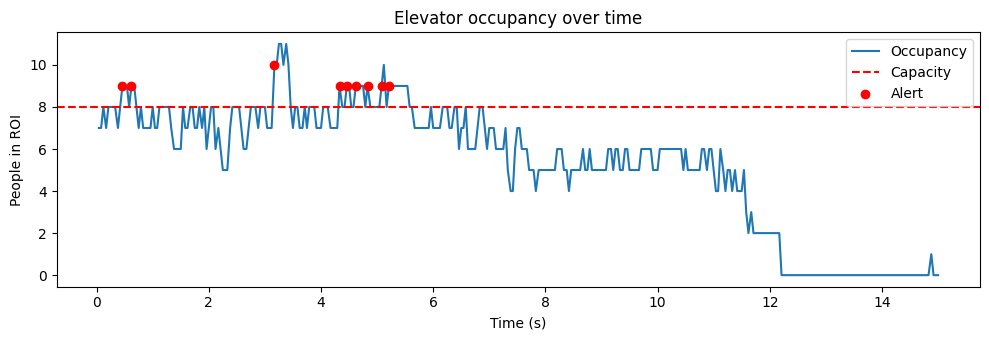

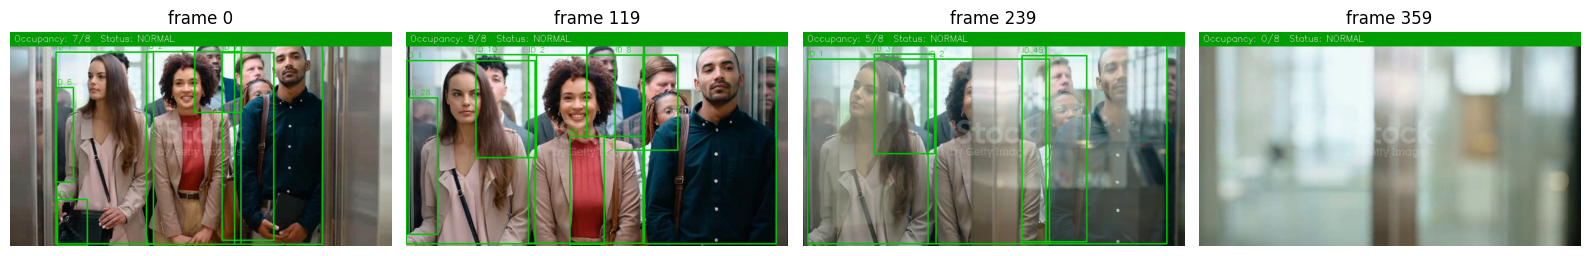


9 evidence snapshot(s) saved to /kaggle/working/elevator_outputs/evidence_snapshots


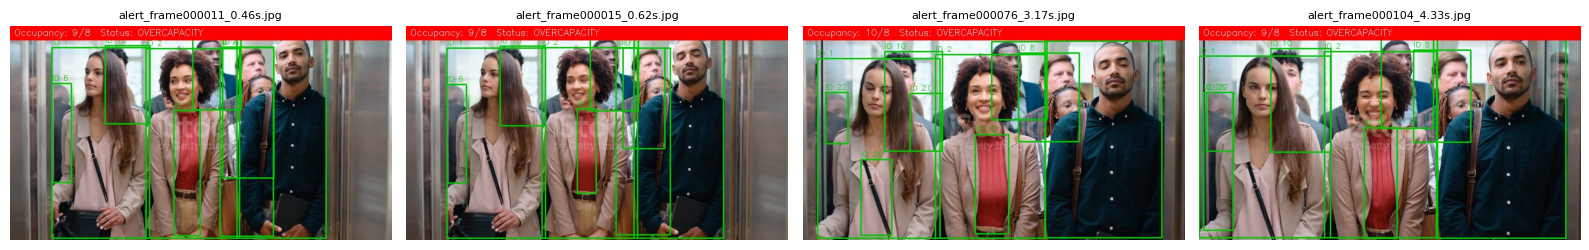


Total distinct overcapacity incidents: 9
 start_time_sec  end_time_sec  duration_frames  peak_occupancy
           0.46          0.54                3               9
           0.62          0.67                2               9
           3.17          3.42                7              11
           4.33          4.33                1               9
           4.46          4.50                2               9
           4.62          4.75                4               9
           4.83          4.83                1               9
           5.08          5.12                2              10
           5.21          5.54                9               9

FINAL SUMMARY REPORT
                     mode: pre-trained
               model_path: yolov8n.pt
         frames_processed: 360
         alerts_generated: 9
           peak_occupancy: 11
            avg_occupancy: 5.3
   overcapacity_incidents: 9
     annotated_video_path: /kaggle/working/elevator_outputs/annotated_elevator_

In [1]:
"""
================================================================================
AI-BASED ELEVATOR OCCUPANCY DETECTION SYSTEM — FINAL COMBINED VERSION
================================================================================
This is the complete, final pipeline combining:
  - Optional: fine-tuning a YOLOv8 person detector on MOT17 (real pedestrian
    tracking data) via kagglehub — this is the teammate's contribution.
  - Core: detection + ByteTrack tracking + ROI-based occupancy counting +
    overcapacity alerting + evidence snapshots + CSV event logging.
  - Reporting: summary statistics, an occupancy-over-time graph, and a
    grouped incident history — for review/submission purposes.

You can run this in TWO MODES, controlled by one flag below:
  USE_CUSTOM_TRAINED_MODEL = False  -> uses a pre-trained YOLOv8n (fast, no
                                        training needed, good enough for the
                                        'person' class out of the box)
  USE_CUSTOM_TRAINED_MODEL = True   -> downloads MOT17, converts it to YOLO
                                        format, fine-tunes YOLOv8n on it, and
                                        uses that trained model instead
                                        (~10-15 min extra on a Kaggle GPU)

HOW TO USE ON KAGGLE (from a completely blank notebook):
1. Create a new Kaggle Notebook.
2. Settings (right panel) -> Accelerator: GPU T4 x2.  Internet: On.
3. If USE_CUSTOM_TRAINED_MODEL = False, you also need a demo video attached:
   "+ Add Input" -> search "crowd video yolov8 people number monitoring"
   (contains sample.mp4). If True, MOT17 is auto-downloaded and a demo video
   is built from it automatically — no video dataset attachment needed.
4. Paste this whole file into one cell (or split by "# ============ CELL n"
   markers into separate cells for step-by-step / grading purposes).
5. Run top to bottom.

ALL outputs land under /kaggle/working/elevator_outputs/:
  annotated_elevator_output.mp4  -> full video with boxes, IDs, occupancy banner
  evidence_snapshots/            -> snapshot images at overcapacity moments
  elevator_events_report.csv     -> per-frame event log
  occupancy_graph.png            -> occupancy-over-time chart
  event_history.csv              -> grouped incident summary
  run_summary.csv                -> final one-row summary of the whole run
================================================================================
"""

# ============ CELL 1: Setup & installs ============
import subprocess


def _pip_install(*packages: str) -> None:
    subprocess.run(["pip", "install", "-q", *packages], check=True)


_pip_install("ultralytics", "kagglehub", "opencv-python-headless", "pandas", "numpy", "tqdm")

import os
import re
import csv
import glob
import shutil
import random
import configparser
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available(), "| device:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# ============ CELL 2: Master configuration ============
# >>> THE ONE SWITCH THAT MATTERS <<<
USE_CUSTOM_TRAINED_MODEL = False   # True = fine-tune on MOT17 first (slower, one-time)

CONFIG: Dict[str, Any] = {
    "WORK_DIR": "/kaggle/working" if os.path.isdir("/kaggle/working") else "/tmp/elevator_project",

    # --- MOT17 conversion + training (only used if USE_CUSTOM_TRAINED_MODEL=True) ---
    "FRAME_STRIDE": 2,
    "MIN_VISIBILITY": 0.2,
    "VAL_FRACTION": 0.2,
    "MAX_IMAGES_PER_SPLIT": 4000,
    "EPOCHS": 15,
    "IMGSZ": 640,
    "BATCH": 16,
    "BASE_MODEL": "yolov8n.pt",
    "PATIENCE": 8,

    # --- Occupancy / inference pipeline (always used) ---
    "CAPACITY": 8,                 # >>> SET TO YOUR REAL ELEVATOR'S MAX OCCUPANCY <<<
    "DETECT_CONF": 0.35,
    "TRACKER": "bytetrack.yaml",
    "ALERT_COOLDOWN_FRAMES": 15,
    "DEMO_VIDEO_FPS": 10,
    "ROI_POLYGON": None,           # None = whole frame; else [(x1,y1),(x2,y2),(x3,y3),(x4,y4)]
}

WORK_DIR = Path(CONFIG["WORK_DIR"])
YOLO_DATASET_DIR = WORK_DIR / "yolo_dataset"
RUNS_DIR = WORK_DIR / "runs"
OUTPUT_DIR = WORK_DIR / "elevator_outputs"
EVIDENCE_DIR = OUTPUT_DIR / "evidence_snapshots"
for d in (WORK_DIR, YOLO_DATASET_DIR, RUNS_DIR, OUTPUT_DIR, EVIDENCE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR)
print("Mode:", "CUSTOM-TRAINED MODEL (MOT17)" if USE_CUSTOM_TRAINED_MODEL else "PRE-TRAINED MODEL (fast path)")


# ============ CELL 3: (Only if training) Download + convert MOT17 ============
MODEL_PATH: str  # this will hold whichever model we end up using
DEMO_VIDEO_SOURCE: Optional[str] = None  # path to a video to run the demo on

if USE_CUSTOM_TRAINED_MODEL:
    import kagglehub

    DATASET_ROOT = kagglehub.dataset_download("ahmedsamir1598/mot17challenge")
    print("MOT17 downloaded to:", DATASET_ROOT)

    def find_sequences(root: str) -> List[str]:
        seqs = []
        for dirpath, dirnames, filenames in os.walk(root):
            if "img1" in dirnames and os.path.isfile(os.path.join(dirpath, "gt", "gt.txt")):
                seqs.append(dirpath)
        return sorted(seqs)

    def dedupe_by_base_sequence(seq_dirs: List[str]) -> List[str]:
        groups: Dict[str, List[str]] = {}
        for s in seq_dirs:
            base = re.sub(r"-(DPM|FRCNN|SDP)$", "", os.path.basename(s))
            groups.setdefault(base, []).append(s)
        return sorted(v[0] for v in (sorted(v) for v in groups.values()))

    all_sequences = find_sequences(DATASET_ROOT)
    unique_sequences = dedupe_by_base_sequence(all_sequences)
    print(f"Using {len(unique_sequences)} unique MOT17 sequences.")
    assert unique_sequences, "No MOT-style sequences found — check DATASET_ROOT structure."

    def read_seqinfo(seq_dir: str) -> Tuple[Optional[int], Optional[int]]:
        ini_path = os.path.join(seq_dir, "seqinfo.ini")
        if os.path.isfile(ini_path):
            cfg = configparser.ConfigParser()
            cfg.read(ini_path)
            if "Sequence" in cfg:
                return (cfg["Sequence"].getint("imWidth", fallback=None),
                        cfg["Sequence"].getint("imHeight", fallback=None))
        return None, None

    def convert_sequence_to_yolo(seq_dir, images_out, labels_out, frame_stride=1,
                                  min_vis=0.2, max_images=None) -> int:
        img_dir = os.path.join(seq_dir, "img1")
        gt_path = os.path.join(seq_dir, "gt", "gt.txt")
        seq_name = os.path.basename(seq_dir)
        w_cfg, h_cfg = read_seqinfo(seq_dir)

        frame_boxes: Dict[int, List[Tuple[float, float, float, float]]] = {}
        with open(gt_path) as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 9:
                    continue
                frame, tid, l, t, bw, bh, conf, cls, vis = parts[:9]
                frame = int(frame)
                cls, vis, conf = int(float(cls)), float(vis), float(conf)
                if cls != 1 or conf == 0 or vis < min_vis:
                    continue
                frame_boxes.setdefault(frame, []).append((float(l), float(t), float(bw), float(bh)))

        img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
        written = 0
        for img_path in img_files:
            if max_images is not None and written >= max_images:
                break
            frame_num = int(os.path.splitext(os.path.basename(img_path))[0])
            if frame_num % frame_stride != 0:
                continue
            if w_cfg and h_cfg:
                w, h = w_cfg, h_cfg
            else:
                im = cv2.imread(img_path)
                if im is None:
                    continue
                h, w = im.shape[:2]

            boxes = frame_boxes.get(frame_num, [])
            out_name = f"{seq_name}_{frame_num:06d}"
            shutil.copy(img_path, os.path.join(images_out, out_name + ".jpg"))

            lines = []
            for (l, t, bw, bh) in boxes:
                xc, yc = (l + bw / 2) / w, (t + bh / 2) / h
                nw, nh = bw / w, bh / h
                xc, yc, nw, nh = [min(max(v, 0.0), 1.0) for v in (xc, yc, nw, nh)]
                lines.append(f"0 {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            with open(os.path.join(labels_out, out_name + ".txt"), "w") as lf:
                lf.write("\n".join(lines))
            written += 1
        return written

    random.shuffle(unique_sequences)
    n_val = max(1, round(len(unique_sequences) * CONFIG["VAL_FRACTION"]))
    val_sequences = unique_sequences[:n_val]
    train_sequences = unique_sequences[n_val:] or unique_sequences[:1]

    print("Train sequences:", [os.path.basename(s) for s in train_sequences])
    print("Val sequences:  ", [os.path.basename(s) for s in val_sequences])

    split_counts = {}
    for split, seqs in [("train", train_sequences), ("val", val_sequences)]:
        images_out = YOLO_DATASET_DIR / "images" / split
        labels_out = YOLO_DATASET_DIR / "labels" / split
        images_out.mkdir(parents=True, exist_ok=True)
        labels_out.mkdir(parents=True, exist_ok=True)

        per_seq_cap = max(1, CONFIG["MAX_IMAGES_PER_SPLIT"] // max(1, len(seqs))) \
            if CONFIG["MAX_IMAGES_PER_SPLIT"] else None

        total = 0
        for s in tqdm(seqs, desc=f"Converting {split}"):
            total += convert_sequence_to_yolo(
                s, str(images_out), str(labels_out),
                frame_stride=CONFIG["FRAME_STRIDE"], min_vis=CONFIG["MIN_VISIBILITY"],
                max_images=per_seq_cap,
            )
        split_counts[split] = total
        print(f"{split}: wrote {total} image/label pairs")

    assert split_counts["train"] > 0, "No training images generated — check dataset paths."

    data_yaml_path = YOLO_DATASET_DIR / "data.yaml"
    data_yaml_path.write_text(
        f"path: {YOLO_DATASET_DIR}\ntrain: images/train\nval: images/val\nnames:\n  0: person\n"
    )
    print(data_yaml_path.read_text())


# ============ CELL 4: (Only if training) Fine-tune YOLOv8 on MOT17 ============
if USE_CUSTOM_TRAINED_MODEL:
    detector_model = YOLO(CONFIG["BASE_MODEL"])
    train_results = detector_model.train(
        data=str(data_yaml_path),
        epochs=CONFIG["EPOCHS"], imgsz=CONFIG["IMGSZ"], batch=CONFIG["BATCH"],
        patience=CONFIG["PATIENCE"], device=DEVICE,
        project=str(RUNS_DIR), name="elevator_person_detector", exist_ok=True, verbose=True,
    )
    MODEL_PATH = str(Path(train_results.save_dir) / "weights" / "best.pt")
    assert os.path.isfile(MODEL_PATH), "Training did not produce best.pt — check logs above."
    print("Custom-trained weights saved to:", MODEL_PATH)

    val_model = YOLO(MODEL_PATH)
    metrics = val_model.val(data=str(data_yaml_path), device=DEVICE)
    print("mAP50:", metrics.box.map50, "| mAP50-95:", metrics.box.map)

    # Build a demo video by stitching a held-out MOT17 sequence's frames together
    def images_to_video(img_dir: str, output_path: str, fps: int = 10) -> Tuple[str, int, int]:
        img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
        if not img_files:
            raise ValueError(f"No frames found in {img_dir}")
        first = cv2.imread(img_files[0])
        h, w = first.shape[:2]
        writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        for f in img_files:
            writer.write(cv2.imread(f))
        writer.release()
        return output_path, w, h

    demo_source_seq = val_sequences[0] if val_sequences else train_sequences[0]
    demo_img_dir = os.path.join(demo_source_seq, "img1")
    demo_video_path = str(OUTPUT_DIR / "demo_elevator_feed.mp4")
    DEMO_VIDEO_SOURCE, demo_w, demo_h = images_to_video(demo_img_dir, demo_video_path, fps=CONFIG["DEMO_VIDEO_FPS"])
    print(f"Demo video built from {os.path.basename(demo_source_seq)}: {DEMO_VIDEO_SOURCE} ({demo_w}x{demo_h})")

else:
    # Fast path: use a pre-trained YOLOv8n directly, no training needed.
    MODEL_PATH = CONFIG["BASE_MODEL"]  # e.g. 'yolov8n.pt' -> auto-downloads via ultralytics
    print(f"Using pre-trained model directly: {MODEL_PATH} (no training).")

    # Locate an attached demo/test video under /kaggle/input
    VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv")

    def find_video_files(root: Path) -> List[Path]:
        found = []
        if not root.exists():
            return found
        for ext in VIDEO_EXTENSIONS:
            found.extend(root.rglob(f"*{ext}"))
        return sorted(found)

    found_videos = find_video_files(Path("/kaggle/input"))

    # Some datasets (e.g. the "crowd-video-yolov8-people-number-monitoring" one)
    # ship BOTH the original source clip (under a "sample1/" or similar folder)
    # AND a previously-generated low-detection output clip (under "runs/detect/
    # predict/"). Alphabetical sort can pick the wrong one, so we explicitly
    # prefer any path that does NOT look like a prior run's output directory.
    def _looks_like_prior_output(p: Path) -> bool:
        lowered = str(p).lower()
        return any(marker in lowered for marker in ("runs/detect", "runs\\detect", "/predict/", "\\predict\\"))

    preferred_videos = [v for v in found_videos if not _looks_like_prior_output(v)]

    if preferred_videos:
        DEMO_VIDEO_SOURCE = str(preferred_videos[0])
        print(f"Found {len(found_videos)} video(s); {len(preferred_videos)} preferred (non-output) candidate(s).")
        print(f"Using: {DEMO_VIDEO_SOURCE}")
    elif found_videos:
        # Fall back to whatever was found, even if it looks like a prior output.
        DEMO_VIDEO_SOURCE = str(found_videos[0])
        print(f"Found {len(found_videos)} video(s), all look like prior-run outputs. Using: {DEMO_VIDEO_SOURCE}")
        print("If results look off (e.g. very low occupancy counts), manually set "
              "DEMO_VIDEO_SOURCE to the correct source clip path.")
    else:
        DEMO_VIDEO_SOURCE = None
        print("WARNING: No video found under /kaggle/input. Attach a video dataset "
              "(see DATASET_GUIDE.md), or set USE_CUSTOM_TRAINED_MODEL = True to auto-build one from MOT17.")


# ============ CELL 5: The core detector/tracker/alerting class ============
class ElevatorOccupancyDetector:
    """
    Ties together detection (YOLO), tracking (ByteTrack), ROI-based occupancy
    counting, overcapacity alerting, evidence snapshot saving, and CSV event
    logging into a single streaming video-processing pipeline.
    """

    def __init__(self, model_path: str, capacity: int, roi_polygon=None, conf: float = 0.35,
                 tracker: str = "bytetrack.yaml", alert_cooldown_frames: int = 15,
                 evidence_dir: str = "evidence") -> None:
        self.model = YOLO(model_path)
        self.capacity = capacity
        self.roi_polygon = roi_polygon  # list[(x, y), ...] pixel coords, or None = whole frame
        self.conf = conf
        self.tracker = tracker
        self.alert_cooldown_frames = alert_cooldown_frames
        self.evidence_dir = evidence_dir
        os.makedirs(evidence_dir, exist_ok=True)
        self._last_alert_frame = -10 ** 9
        self._prev_status = "NORMAL"

    def _in_roi(self, cx: float, cy: float) -> bool:
        if self.roi_polygon is None:
            return True
        pts = np.array(self.roi_polygon, dtype=np.int32)
        return cv2.pointPolygonTest(pts, (float(cx), float(cy)), False) >= 0

    def run(self, video_path: str, output_video_path: str, csv_path: str,
            device: Optional[Any] = None) -> Dict[str, Any]:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")
        src_fps = cap.get(cv2.CAP_PROP_FPS) or 10
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()

        writer = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*"mp4v"), src_fps, (w, h))
        csv_rows: List[Dict[str, Any]] = []
        frame_idx = 0
        alerts_generated = 0
        occupancy_history: List[int] = []

        results_stream = self.model.track(
            source=video_path, conf=self.conf, persist=True,
            tracker=self.tracker, stream=True, verbose=False, device=device,
        )

        for result in results_stream:
            frame_idx += 1
            frame = result.orig_img.copy()
            timestamp_sec = round(frame_idx / src_fps, 2)

            ids_in_roi = []
            if result.boxes is not None and result.boxes.id is not None:
                boxes = result.boxes.xyxy.cpu().numpy()
                ids = result.boxes.id.cpu().numpy().astype(int)
                for (x1, y1, x2, y2), tid in zip(boxes, ids):
                    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
                    inside = self._in_roi(cx, cy)
                    color = (0, 200, 0) if inside else (150, 150, 150)
                    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                    cv2.putText(frame, f"ID {tid}", (int(x1), max(int(y1) - 6, 10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                    if inside:
                        ids_in_roi.append(tid)

            count = len(set(ids_in_roi))
            occupancy_history.append(count)
            status = "OVERCAPACITY" if count > self.capacity else "NORMAL"

            if self.roi_polygon is not None:
                cv2.polylines(frame, [np.array(self.roi_polygon, dtype=np.int32)], True, (255, 200, 0), 2)

            banner_color = (0, 0, 255) if status == "OVERCAPACITY" else (0, 160, 0)
            cv2.rectangle(frame, (0, 0), (w, 30), banner_color, -1)
            cv2.putText(frame, f"Occupancy: {count}/{self.capacity}  Status: {status}",
                        (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

            event_type, snapshot_file = "", ""
            became_overcapacity = status == "OVERCAPACITY" and self._prev_status != "OVERCAPACITY"
            cooldown_elapsed = (frame_idx - self._last_alert_frame) >= self.alert_cooldown_frames
            if status == "OVERCAPACITY" and (became_overcapacity or cooldown_elapsed):
                event_type = "OVERCAPACITY_ALERT"
                snapshot_file = os.path.join(self.evidence_dir, f"alert_frame{frame_idx:06d}_{timestamp_sec}s.jpg")
                cv2.imwrite(snapshot_file, frame)
                self._last_alert_frame = frame_idx
                alerts_generated += 1

            self._prev_status = status
            csv_rows.append({
                "frame": frame_idx, "timestamp_sec": timestamp_sec,
                "occupancy_count": count, "capacity": self.capacity,
                "status": status, "event_type": event_type, "evidence_snapshot": snapshot_file,
            })
            writer.write(frame)

        writer.release()

        fieldnames = ["frame", "timestamp_sec", "occupancy_count", "capacity",
                      "status", "event_type", "evidence_snapshot"]
        with open(csv_path, "w", newline="") as f:
            w_csv = csv.DictWriter(f, fieldnames=fieldnames)
            w_csv.writeheader()
            w_csv.writerows(csv_rows)

        return {
            "frames_processed": frame_idx,
            "alerts_generated": alerts_generated,
            "peak_occupancy": max(occupancy_history) if occupancy_history else 0,
            "avg_occupancy": round(float(np.mean(occupancy_history)), 2) if occupancy_history else 0,
            "csv_path": csv_path,
            "annotated_video_path": output_video_path,
        }


print("ElevatorOccupancyDetector class ready.")


# ============ CELL 6: Run the pipeline ============
if DEMO_VIDEO_SOURCE is None:
    raise ValueError(
        "No video available to process. Either attach a video dataset (see "
        "DATASET_GUIDE.md) or set USE_CUSTOM_TRAINED_MODEL = True to auto-build "
        "a demo video from MOT17."
    )

roi_polygon = CONFIG["ROI_POLYGON"]
# Example: restrict counting to the central 70% of the frame instead of the whole image
# (uncomment and adjust once you know your video's resolution):
# margin_x, margin_y = int(demo_w * 0.15), int(demo_h * 0.15)
# roi_polygon = [(margin_x, margin_y), (demo_w - margin_x, margin_y),
#                (demo_w - margin_x, demo_h - margin_y), (margin_x, demo_h - margin_y)]

detector_app = ElevatorOccupancyDetector(
    model_path=MODEL_PATH,
    capacity=CONFIG["CAPACITY"],
    roi_polygon=roi_polygon,
    conf=CONFIG["DETECT_CONF"],
    tracker=CONFIG["TRACKER"],
    alert_cooldown_frames=CONFIG["ALERT_COOLDOWN_FRAMES"],
    evidence_dir=str(EVIDENCE_DIR),
)

annotated_video_path = str(OUTPUT_DIR / "annotated_elevator_output.mp4")
csv_report_path = str(OUTPUT_DIR / "elevator_events_report.csv")

summary = detector_app.run(
    video_path=DEMO_VIDEO_SOURCE,
    output_video_path=annotated_video_path,
    csv_path=csv_report_path,
    device=DEVICE,
)
print("\nRun summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")


# ============ CELL 7: Inspect outputs — table, graph, sample frames ============
df = pd.read_csv(csv_report_path)
print(f"\nLogged {len(df)} frame records | {(df['event_type'] == 'OVERCAPACITY_ALERT').sum()} alerts")
print(df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(df["timestamp_sec"], df["occupancy_count"], label="Occupancy")
ax.axhline(CONFIG["CAPACITY"], color="red", linestyle="--", label="Capacity")
alert_points = df[df["event_type"] == "OVERCAPACITY_ALERT"]
ax.scatter(alert_points["timestamp_sec"], alert_points["occupancy_count"], color="red", zorder=5, label="Alert")
ax.set_xlabel("Time (s)")
ax.set_ylabel("People in ROI")
ax.set_title("Elevator occupancy over time")
ax.legend()
plt.tight_layout()
graph_path = str(OUTPUT_DIR / "occupancy_graph.png")
plt.savefig(graph_path, dpi=150)
plt.show()

# Sample frames from the annotated output video
cap = cv2.VideoCapture(annotated_video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample_indices = sorted(set(np.linspace(0, max(total_frames - 1, 0), num=min(4, total_frames), dtype=int)))

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * len(sample_indices), 4))
if len(sample_indices) == 1:
    axes = [axes]
for ax, idx in zip(axes, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    if ok:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}")
    ax.axis("off")
cap.release()
plt.tight_layout()
plt.show()

evidence_files = sorted(glob.glob(os.path.join(EVIDENCE_DIR, "*.jpg")))
print(f"\n{len(evidence_files)} evidence snapshot(s) saved to {EVIDENCE_DIR}")
if evidence_files:
    n_show = min(4, len(evidence_files))
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for ax, fp in zip(axes, evidence_files[:n_show]):
        img = cv2.imread(fp)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(fp), fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# ============ CELL 8: Event history (grouped overcapacity incidents) ============
def generate_event_history(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["start_time_sec", "end_time_sec", "duration_frames", "peak_occupancy"])
    is_over = (df["status"] == "OVERCAPACITY").astype(int)
    block_id = (is_over.diff() != 0).cumsum()
    incidents = []
    for _, group in df.groupby(block_id):
        if group["status"].iloc[0] != "OVERCAPACITY":
            continue
        incidents.append({
            "start_time_sec": group["timestamp_sec"].iloc[0],
            "end_time_sec": group["timestamp_sec"].iloc[-1],
            "duration_frames": len(group),
            "peak_occupancy": int(group["occupancy_count"].max()),
        })
    return pd.DataFrame(incidents)


event_history_df = generate_event_history(df)
event_history_path = str(OUTPUT_DIR / "event_history.csv")
event_history_df.to_csv(event_history_path, index=False)
print(f"\nTotal distinct overcapacity incidents: {len(event_history_df)}")
if not event_history_df.empty:
    print(event_history_df.to_string(index=False))
else:
    print("No overcapacity incidents detected.")


# ============ CELL 9: Final summary report ============
report: Dict[str, Any] = {
    "mode": "custom-trained (MOT17)" if USE_CUSTOM_TRAINED_MODEL else "pre-trained",
    "model_path": MODEL_PATH,
    "frames_processed": summary["frames_processed"],
    "alerts_generated": summary["alerts_generated"],
    "peak_occupancy": summary["peak_occupancy"],
    "avg_occupancy": summary["avg_occupancy"],
    "overcapacity_incidents": len(event_history_df),
    "annotated_video_path": annotated_video_path,
    "csv_report_path": csv_report_path,
    "event_history_path": event_history_path,
    "graph_path": graph_path,
    "evidence_dir": str(EVIDENCE_DIR),
}
if USE_CUSTOM_TRAINED_MODEL:
    report["val_mAP50"] = float(metrics.box.map50)
    report["val_mAP50_95"] = float(metrics.box.map)

print("\n" + "=" * 55)
print("FINAL SUMMARY REPORT")
print("=" * 55)
for k, v in report.items():
    print(f"{k:>25}: {v}")

pd.Series(report).to_csv(str(OUTPUT_DIR / "run_summary.csv"), header=["value"])
print("\nAll outputs saved under:", OUTPUT_DIR)

In [2]:
from pathlib import Path

batch_dir = Path("/kaggle/working/elevator_outputs/batch_results")

print("Checking if annotated videos exist...\n")
if batch_dir.exists():
    videos = list(batch_dir.rglob("annotated_*.mp4"))
    if videos:
        for v in videos:
            size_mb = v.stat().st_size / (1024 * 1024)
            print(f"  FOUND: {v}  ({size_mb:.2f} MB)")
    else:
        print("  batch_results folder exists but no annotated_*.mp4 files found inside.")
else:
    print("  batch_results folder does NOT exist in this session.")
    print("  This likely means the session restarted and /kaggle/working was wiped.")
    print("  You'll need to re-run the batch processing script again.")

Checking if annotated videos exist...

  batch_results folder does NOT exist in this session.
  This likely means the session restarted and /kaggle/working was wiped.
  You'll need to re-run the batch processing script again.


In [3]:
# ============================================================
# BATCH PROCESSING: Run pipeline on MULTIPLE video clips
# Generates a separate annotated video + CSV + evidence folder
# for EACH video found under /kaggle/input
# ============================================================
import subprocess


def _pip_install(*packages):
    subprocess.run(["pip", "install", "-q", *packages], check=True)


_pip_install("ultralytics", "opencv-python-headless", "pandas", "numpy")

import os
import csv
import glob
from pathlib import Path
from typing import Optional, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# --- Re-define paths (in case session was restarted) ---
OUTPUT_DIR = Path("/kaggle/working/elevator_outputs")
BATCH_DIR = OUTPUT_DIR / "batch_results"
BATCH_DIR.mkdir(parents=True, exist_ok=True)
CAPACITY = 8  # keep consistent with your main run, or change per test


# --- Self-contained detector class (same as the main pipeline's) ---
class ElevatorOccupancyDetector:
    def __init__(self, model_path: str, capacity: int, roi_polygon=None, conf: float = 0.35,
                 tracker: str = "bytetrack.yaml", alert_cooldown_frames: int = 15,
                 evidence_dir: str = "evidence") -> None:
        self.model = YOLO(model_path)
        self.capacity = capacity
        self.roi_polygon = roi_polygon
        self.conf = conf
        self.tracker = tracker
        self.alert_cooldown_frames = alert_cooldown_frames
        self.evidence_dir = evidence_dir
        os.makedirs(evidence_dir, exist_ok=True)
        self._last_alert_frame = -10 ** 9
        self._prev_status = "NORMAL"

    def _in_roi(self, cx: float, cy: float) -> bool:
        if self.roi_polygon is None:
            return True
        pts = np.array(self.roi_polygon, dtype=np.int32)
        return cv2.pointPolygonTest(pts, (float(cx), float(cy)), False) >= 0

    def run(self, video_path: str, output_video_path: str, csv_path: str,
            device: Optional[Any] = None) -> Dict[str, Any]:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")
        src_fps = cap.get(cv2.CAP_PROP_FPS) or 10
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()

        writer = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*"mp4v"), src_fps, (w, h))
        csv_rows: List[Dict[str, Any]] = []
        frame_idx = 0
        alerts_generated = 0
        occupancy_history: List[int] = []

        results_stream = self.model.track(
            source=video_path, conf=self.conf, persist=True,
            tracker=self.tracker, stream=True, verbose=False, device=device,
        )

        for result in results_stream:
            frame_idx += 1
            frame = result.orig_img.copy()
            timestamp_sec = round(frame_idx / src_fps, 2)

            ids_in_roi = []
            if result.boxes is not None and result.boxes.id is not None:
                boxes = result.boxes.xyxy.cpu().numpy()
                ids = result.boxes.id.cpu().numpy().astype(int)
                for (x1, y1, x2, y2), tid in zip(boxes, ids):
                    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
                    inside = self._in_roi(cx, cy)
                    color = (0, 200, 0) if inside else (150, 150, 150)
                    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                    cv2.putText(frame, f"ID {tid}", (int(x1), max(int(y1) - 6, 10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                    if inside:
                        ids_in_roi.append(tid)

            count = len(set(ids_in_roi))
            occupancy_history.append(count)
            status = "OVERCAPACITY" if count > self.capacity else "NORMAL"

            if self.roi_polygon is not None:
                cv2.polylines(frame, [np.array(self.roi_polygon, dtype=np.int32)], True, (255, 200, 0), 2)

            banner_color = (0, 0, 255) if status == "OVERCAPACITY" else (0, 160, 0)
            cv2.rectangle(frame, (0, 0), (w, 30), banner_color, -1)
            cv2.putText(frame, f"Occupancy: {count}/{self.capacity}  Status: {status}",
                        (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

            event_type, snapshot_file = "", ""
            became_overcapacity = status == "OVERCAPACITY" and self._prev_status != "OVERCAPACITY"
            cooldown_elapsed = (frame_idx - self._last_alert_frame) >= self.alert_cooldown_frames
            if status == "OVERCAPACITY" and (became_overcapacity or cooldown_elapsed):
                event_type = "OVERCAPACITY_ALERT"
                snapshot_file = os.path.join(self.evidence_dir, f"alert_frame{frame_idx:06d}_{timestamp_sec}s.jpg")
                cv2.imwrite(snapshot_file, frame)
                self._last_alert_frame = frame_idx
                alerts_generated += 1

            self._prev_status = status
            csv_rows.append({
                "frame": frame_idx, "timestamp_sec": timestamp_sec,
                "occupancy_count": count, "capacity": self.capacity,
                "status": status, "event_type": event_type, "evidence_snapshot": snapshot_file,
            })
            writer.write(frame)

        writer.release()

        fieldnames = ["frame", "timestamp_sec", "occupancy_count", "capacity",
                      "status", "event_type", "evidence_snapshot"]
        with open(csv_path, "w", newline="") as f:
            w_csv = csv.DictWriter(f, fieldnames=fieldnames)
            w_csv.writeheader()
            w_csv.writerows(csv_rows)

        return {
            "frames_processed": frame_idx,
            "alerts_generated": alerts_generated,
            "peak_occupancy": max(occupancy_history) if occupancy_history else 0,
            "avg_occupancy": round(float(np.mean(occupancy_history)), 2) if occupancy_history else 0,
            "csv_path": csv_path,
            "annotated_video_path": output_video_path,
        }


print("ElevatorOccupancyDetector class ready (self-contained).")

# --- Find ALL video files under /kaggle/input ---
VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv")

def find_video_files(root: Path):
    found = []
    if not root.exists():
        return found
    for ext in VIDEO_EXTENSIONS:
        found.extend(root.rglob(f"*{ext}"))
    return sorted(found)

# Skip any file that looks like a prior run's output (avoids the earlier bug)
def looks_like_prior_output(p: Path) -> bool:
    lowered = str(p).lower()
    return any(m in lowered for m in ("runs/detect", "runs\\detect", "/predict/", "\\predict\\"))

all_videos = find_video_files(Path("/kaggle/input"))
videos_to_process = [v for v in all_videos if not looks_like_prior_output(v)]

print(f"Found {len(all_videos)} total video(s), {len(videos_to_process)} usable (non-output) video(s):")
for v in videos_to_process:
    print(f"  - {v}")

if not videos_to_process:
    raise ValueError(
        "No usable videos found. Attach more video datasets via '+ Add Input' "
        "(e.g. search 'crowd detection video' or 'crowduit') and re-run."
    )

# --- IMPORTANT: requires ElevatorOccupancyDetector class already defined ---
# (from the main elevator_final_complete.py run in this same session).
# If you get a NameError here, re-run the main pipeline file's CELL 1 and
# CELL 5 (imports + class definition) first, in this same session.

MODEL_PATH = "yolov8n.pt"  # pre-trained, fast path

batch_summaries = []

for i, video_path in enumerate(videos_to_process, start=1):
    video_name = video_path.stem  # filename without extension
    print(f"\n{'='*60}")
    print(f"Processing video {i}/{len(videos_to_process)}: {video_name}")
    print(f"{'='*60}")

    # Each video gets its own subfolder so outputs never overwrite each other
    video_out_dir = BATCH_DIR / video_name
    evidence_dir = video_out_dir / "evidence_snapshots"
    evidence_dir.mkdir(parents=True, exist_ok=True)

    detector_app = ElevatorOccupancyDetector(
        model_path=MODEL_PATH,
        capacity=CAPACITY,
        roi_polygon=None,
        conf=0.35,
        tracker="bytetrack.yaml",
        alert_cooldown_frames=15,
        evidence_dir=str(evidence_dir),
    )

    annotated_video_path = str(video_out_dir / f"annotated_{video_name}.mp4")
    csv_report_path = str(video_out_dir / f"report_{video_name}.csv")

    try:
        summary = detector_app.run(
            video_path=str(video_path),
            output_video_path=annotated_video_path,
            csv_path=csv_report_path,
            device=0,
        )
        summary["video_name"] = video_name
        summary["source_path"] = str(video_path)
        batch_summaries.append(summary)

        print(f"Done: {summary['frames_processed']} frames | "
              f"peak={summary['peak_occupancy']} | alerts={summary['alerts_generated']}")
    except Exception as e:
        print(f"FAILED on {video_name}: {e}")

# --- Combined summary across all processed videos ---
batch_df = pd.DataFrame(batch_summaries)
batch_summary_path = str(BATCH_DIR / "batch_summary.csv")
batch_df.to_csv(batch_summary_path, index=False)

print(f"\n{'='*60}")
print(f"BATCH COMPLETE — {len(batch_summaries)}/{len(videos_to_process)} videos processed successfully")
print(f"{'='*60}")
print(batch_df.to_string(index=False))
print(f"\nAll outputs saved under: {BATCH_DIR}")
print(f"Combined summary: {batch_summary_path}")

ElevatorOccupancyDetector class ready (self-contained).
Found 6 total video(s), 5 usable (non-output) video(s):
  - /kaggle/input/datasets/jayantvaibhav/viedo-data/istockphoto-1834484979-640_adpp_is.mp4
  - /kaggle/input/datasets/jayantvaibhav/viedo-data/video_2026-07-21_19-06-41.mp4
  - /kaggle/input/datasets/jayantvaibhav/viedos/WhatsApp Video 2026-07-24 at 10.12.30 AM.mp4
  - /kaggle/input/datasets/jayantvaibhav/viedosss/video_2026-07-24_17-53-13.mp4
  - /kaggle/input/notebooks/stpeteishii/crowd-video-yolov8-people-number-monitoring/sample1/sample.mp4

Processing video 1/5: istockphoto-1834484979-640_adpp_is
Done: 360 frames | peak=11 | alerts=9

Processing video 2/5: video_2026-07-21_19-06-41
Done: 501 frames | peak=9 | alerts=2

Processing video 3/5: WhatsApp Video 2026-07-24 at 10.12.30 AM
Done: 239 frames | peak=5 | alerts=0

Processing video 4/5: video_2026-07-24_17-53-13
Done: 563 frames | peak=6 | alerts=0

Processing video 5/5: sample
Done: 750 frames | peak=21 | alerts=60



In [4]:
# ============ Re-encode videos to H.264 for compatibility ============
# OpenCV's mp4v codec often isn't playable in standard media players.
# ffmpeg re-encodes to H.264, which plays everywhere (Windows, phones, browsers).

import subprocess
from pathlib import Path

batch_dir = Path("/kaggle/working/elevator_outputs/batch_results")

# Find all annotated videos
videos = list(batch_dir.rglob("annotated_*.mp4"))
print(f"Found {len(videos)} video(s) to re-encode:\n")

for video_path in videos:
    output_path = video_path.parent / f"playable_{video_path.name}"
    print(f"Re-encoding: {video_path.name} -> {output_path.name}")

    result = subprocess.run(
        [
            "ffmpeg", "-y",              # -y = overwrite without asking
            "-i", str(video_path),       # input file
            "-vcodec", "libx264",        # H.264 codec (universally playable)
            "-pix_fmt", "yuv420p",       # ensures compatibility with most players
            "-crf", "23",                # quality (lower = better quality, 18-28 is typical range)
            str(output_path),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        size_mb = output_path.stat().st_size / (1024 * 1024)
        print(f"  Done: {output_path}  ({size_mb:.2f} MB)\n")
    else:
        print(f"  FAILED: {result.stderr[-500:]}\n")  # show last 500 chars of error

print("Re-encoding complete. Download the 'playable_*.mp4' files instead of the original ones.")

Found 5 video(s) to re-encode:

Re-encoding: annotated_video_2026-07-24_17-53-13.mp4 -> playable_annotated_video_2026-07-24_17-53-13.mp4
  Done: /kaggle/working/elevator_outputs/batch_results/video_2026-07-24_17-53-13/playable_annotated_video_2026-07-24_17-53-13.mp4  (1.84 MB)

Re-encoding: annotated_istockphoto-1834484979-640_adpp_is.mp4 -> playable_annotated_istockphoto-1834484979-640_adpp_is.mp4
  Done: /kaggle/working/elevator_outputs/batch_results/istockphoto-1834484979-640_adpp_is/playable_annotated_istockphoto-1834484979-640_adpp_is.mp4  (1.83 MB)

Re-encoding: annotated_video_2026-07-21_19-06-41.mp4 -> playable_annotated_video_2026-07-21_19-06-41.mp4
  Done: /kaggle/working/elevator_outputs/batch_results/video_2026-07-21_19-06-41/playable_annotated_video_2026-07-21_19-06-41.mp4  (2.02 MB)

Re-encoding: annotated_sample.mp4 -> playable_annotated_sample.mp4
  Done: /kaggle/working/elevator_outputs/batch_results/sample/playable_annotated_sample.mp4  (31.64 MB)

Re-encoding: annota

In [5]:
import os

print("Currently attached datasets under /kaggle/input:\n")
for entry in sorted(os.listdir("/kaggle/input")):
    full_path = os.path.join("/kaggle/input", entry)
    print(f"- {entry}")

print("\n\nFull file listing (first 50 files):")
count = 0
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))
        count += 1
        if count >= 50:
            break
    if count >= 50:
        break
        

Currently attached datasets under /kaggle/input:

- datasets
- notebooks


Full file listing (first 50 files):
/kaggle/input/datasets/jayantvaibhav/viedo-data/video_2026-07-21_19-06-41.mp4
/kaggle/input/datasets/jayantvaibhav/viedo-data/istockphoto-1834484979-640_adpp_is.mp4
/kaggle/input/datasets/jayantvaibhav/viedos/WhatsApp Video 2026-07-24 at 10.12.30 AM.mp4
/kaggle/input/datasets/jayantvaibhav/viedosss/video_2026-07-24_17-53-13.mp4
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/__results__.html
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/__notebook_source__.ipynb
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/__resultx__.html
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/__notebook__.ipynb
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/model.h5
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection-model/__output__.json
/kaggle/input/notebooks/ekaterinadranitsyna/crowd-detection

In [6]:
import os

VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv", ".webm")

print("Searching for ALL video files under /kaggle/input...\n")
found = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(VIDEO_EXTENSIONS):
            full_path = os.path.join(root, f)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            found.append((full_path, size_mb))

if found:
    print(f"Found {len(found)} video file(s):\n")
    for path, size in found:
        print(f"  {path}  ({size:.2f} MB)")
else:
    print("No video files found under /kaggle/input.")

print("\n\nAlso listing all attached dataset/notebook folder names for reference:")
for entry in sorted(os.listdir("/kaggle/input")):
    sub = os.path.join("/kaggle/input", entry)
    if os.path.isdir(sub):
        for sub_entry in sorted(os.listdir(sub)):
            print(f"  {entry}/{sub_entry}")
            

Searching for ALL video files under /kaggle/input...

Found 6 video file(s):

  /kaggle/input/datasets/jayantvaibhav/viedo-data/video_2026-07-21_19-06-41.mp4  (1.30 MB)
  /kaggle/input/datasets/jayantvaibhav/viedo-data/istockphoto-1834484979-640_adpp_is.mp4  (1.15 MB)
  /kaggle/input/datasets/jayantvaibhav/viedos/WhatsApp Video 2026-07-24 at 10.12.30 AM.mp4  (0.70 MB)
  /kaggle/input/datasets/jayantvaibhav/viedosss/video_2026-07-24_17-53-13.mp4  (1.81 MB)
  /kaggle/input/notebooks/stpeteishii/crowd-video-yolov8-people-number-monitoring/runs/detect/predict/sample.mp4  (372.03 MB)
  /kaggle/input/notebooks/stpeteishii/crowd-video-yolov8-people-number-monitoring/sample1/sample.mp4  (29.67 MB)


Also listing all attached dataset/notebook folder names for reference:
  datasets/jayantvaibhav
  notebooks/ekaterinadranitsyna
  notebooks/manojnag
  notebooks/stpeteishii
  notebooks/tarunpaparaju
  notebooks/ubaydulloasatullaev
